# 📑 Tutorials for PyPOTS Imputation Models

## 📀 Preparing the **PhysioNet-2012** dataset for this tutorial

In [20]:
from benchpots.datasets import preprocess_physionet2012

# Load the dataset with artificially missing values
physionet2012_dataset = preprocess_physionet2012(subset="all", rate=0.1)

2025-03-06 16:44:00 [INFO]: You're using dataset physionet_2012, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/physionet_2012
2025-03-06 16:44:00 [INFO]: Dataset physionet_2012 has already been downloaded. Processing directly...
2025-03-06 16:44:00 [INFO]: Dataset physionet_2012 has already been cached. Loading from cache directly...
2025-03-06 16:44:00 [INFO]: Loaded successfully!
2025-03-06 16:44:13 [WARNING]: Note that physionet_2012 has sparse observations in the time series, hence we don't add additional missing values to the training dataset. 
2025-03-06 16:44:13 [INFO]: 69036 values masked out in the val set as ground truth, take 9.97% of the original observed values
2025-03-06 16:44:13 [INFO]: 86324 values masked out in the test set as ground truth, take 10.01% of the original observed values
2025-03-06 16:44:13 [INFO]: Total sample number: 11988
2025-03-06 16:44:13 [I

In [21]:
physionet2012_dataset.keys()

dict_keys(['n_classes', 'n_steps', 'n_features', 'scaler', 'train_X', 'train_y', 'train_ICUType', 'val_X', 'val_y', 'val_ICUType', 'test_X', 'test_y', 'test_ICUType', 'val_X_ori', 'test_X_ori'])

In [22]:
# Assemble the datasets for training, validating, and testing.

dataset_for_training = {
    "X": physionet2012_dataset['train_X'],
}

dataset_for_validating = {
    "X": physionet2012_dataset['val_X'],
    "X_ori": physionet2012_dataset['val_X_ori'],
}

dataset_for_testing = {
    "X": physionet2012_dataset['test_X'],
    "X_ori": physionet2012_dataset['test_X_ori']
}


## División en entrenamiento, validación y testing

- 64% Training 
- 16% Validation
- 20% Testing

In [23]:
dataset_for_testing['X_ori']

array([[[        nan,         nan,         nan, ...,         nan,
         -3.29437627,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
         -3.29437627,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,  

In [24]:
dataset_for_testing['X']

array([[[        nan,         nan,         nan, ...,         nan,
         -3.29437627,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
         -3.29437627,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,  

In [45]:
features = {'Albumin': 'Serum Albumin (g/dL)',
    'ALP': 'Alkaline phosphatase (IU/L)',
    'ALT': 'Alanine transaminase (IU/L)',
    'AST': 'Aspartate transaminase (IU/L)',
    'Bilirubin': 'Bilirubin (mg/dL)',
    'BUN': 'Blood urea nitrogen (mg/dL)',
    'Cholesterol': 'Cholesterol (mg/dL)',
    'Creatinine': 'Serum creatinine (mg/dL)',
    'DiasABP': 'Invasive diastolic arterial blood pressure (mmHg)',
    'FiO2': 'Fractional inspired O2 (0-1)',
    'GCS': 'Glasgow Coma Score (3-15)',
    'Glucose': 'Serum glucose (mg/dL)',
    'HCO3': 'Serum bicarbonate (mmol/L)',
    'HCT': 'Hematocrit (%)',
    'HR': 'Heart rate (bpm)',
    'K': 'Serum potassium (mEq/L)',
    'Lactate': 'Lactate (mmol/L)',
    'Mg': 'Serum magnesium (mmol/L)',
    'MAP': 'Invasive mean arterial blood pressure (mmHg)',
    'MechVent': 'Mechanical ventilation respiration (0:false or 1:true)',
    'Na': 'Serum sodium (mEq/L)',
    'NIDiasABP': 'Non-invasive diastolic arterial blood pressure (mmHg)',
    'NIMAP': 'Non-invasive mean arterial blood pressure (mmHg)',
    'NISysABP': 'Non-invasive systolic arterial blood pressure (mmHg)',
    'PaCO2': 'partial pressure of arterial CO2 (mmHg)',
    'PaO2': 'Partial pressure of arterial O2 (mmHg)',
    'pH': 'Arterial pH (0-14)',
    'Platelets': 'Platelets (cells/nL)',
    'RespRate': 'Respiration rate (bpm)',
    'SaO2': 'O2 saturation in hemoglobin (%)',
    'SysABP': 'Invasive systolic arterial blood pressure (mmHg)',
    'Temp': 'Temperature (°C)',
    'TroponinI': 'Troponin-I (μg/L)',
    'TroponinT': 'Troponin-T (μg/L)',
    'Urine': 'Urine output (mL)',
    'WBC': 'White blood cell count (cells/nL)',
    'Weight': 'Weight (kg)'}
len(features)

37

In [26]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (2399, 48, 37)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (2399 * 48, 37)

X_reshaped = dataset_for_testing['X'].reshape(-1, 37)

# Ahora X_reshaped tiene la forma (2399 * 48, 37)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(2399), range(48)], names=['Sample', 'Time'])

# Creamos el DataFrame
df = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df

Albumin  ALP  ALT  AST  Bilirubin  BUN  Cholesterol  Creatinine  \
Sample Time                                                                    
0      0         NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       1         NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       2         NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       3         NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       4         NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
...              ...  ...  ...  ...        ...  ...          ...         ...   
2398   43        NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       44        NaN  NaN  NaN  NaN   2.766181  NaN          NaN    0.749063   
       45        NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       46        NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   
       47        NaN  NaN  NaN  NaN        NaN  NaN          NaN         NaN   

              DiasABP      FiO2  ...  Platelets  RespRate      SaO2    SysABP  \
Sample Time                      ...                                            
0      0          NaN       NaN  ...  -0.102168       NaN       NaN -1.320034   
       1          NaN       NaN  ...  -0.285808       NaN       NaN       NaN   
       2          NaN       NaN  ...  -0.102168       NaN       NaN       NaN   
       3          NaN       NaN  ...   0.081471       NaN       NaN       NaN   
       4          NaN       NaN  ...   0.081471       NaN       NaN       NaN   
...               ...       ...  ...        ...       ...       ...       ...   
2398   43   -1.760116       NaN  ...        NaN       NaN -0.254141       NaN   
       44   -1.837668 -0.232244  ...        NaN  0.383416 -0.467325       NaN   
       45   -1.139700       NaN  ...        NaN       NaN  0.854417  0.246054   
       46   -1.837668       NaN  ...        NaN       NaN -0.040957       NaN   
       47   -1.915220       NaN  ...        NaN       NaN -0.382052  0.169660   

             Temp  TroponinI  TroponinT  Urine       WBC    Weight  
Sample Time                                                         
0      0      NaN        NaN   2.390155    NaN -3.294376       NaN  
       1      NaN        NaN  -0.568285    NaN       NaN       NaN  
       2      NaN        NaN   0.352119    NaN       NaN       NaN  
       3      NaN        NaN  -0.371055    NaN       NaN       NaN  
       4      NaN        NaN        NaN    NaN       NaN       NaN  
...           ...        ...        ...    ...       ...       ...  
2398   43     NaN        NaN  -0.568285    NaN  0.834317       NaN  
       44     NaN        NaN  -0.568285    NaN  0.834317  0.002664  
       45     NaN        NaN  -0.568285    NaN  0.834317       NaN  
       46     NaN        NaN  -0.601156    NaN       NaN       NaN  
       47     NaN        NaN  -0.568285    NaN       NaN       NaN  

[115152 rows x 37 columns]

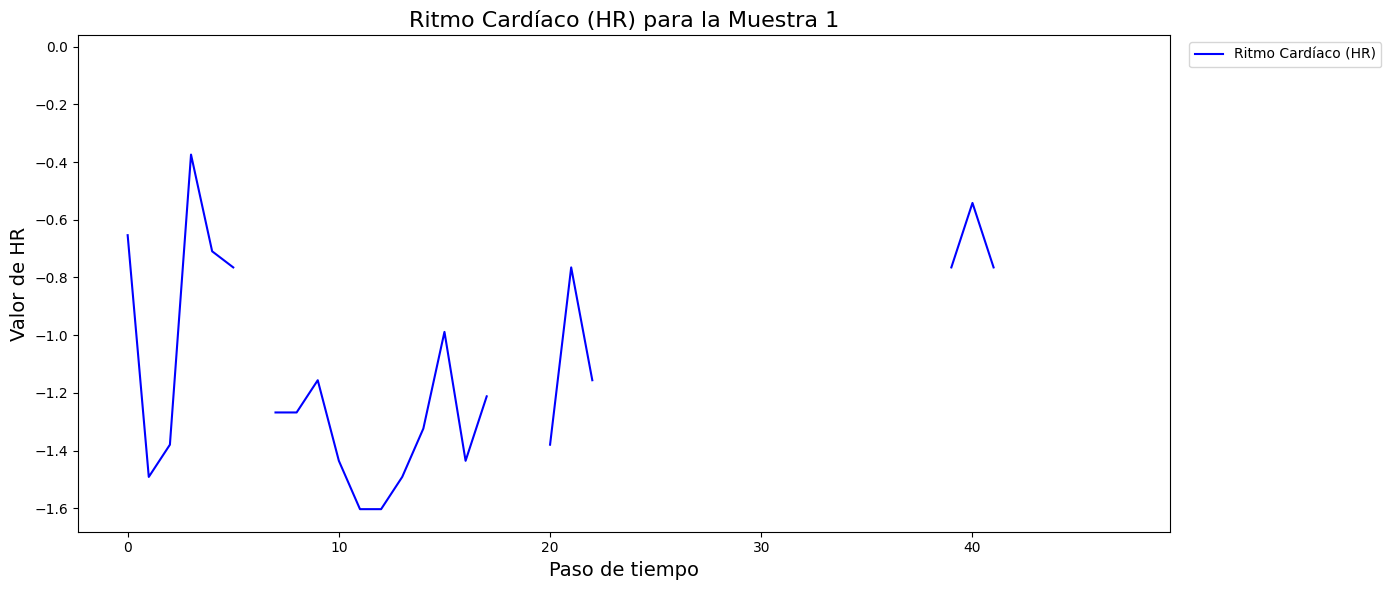

In [27]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(48)  # 48 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['HR', 'NIMAP']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['HR'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HR'], label='Ritmo Cardíaco (HR)', color='b')
    plt.title(f'Ritmo Cardíaco (HR) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HR', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Ritmo Cardíaco (HR) en la muestra.")



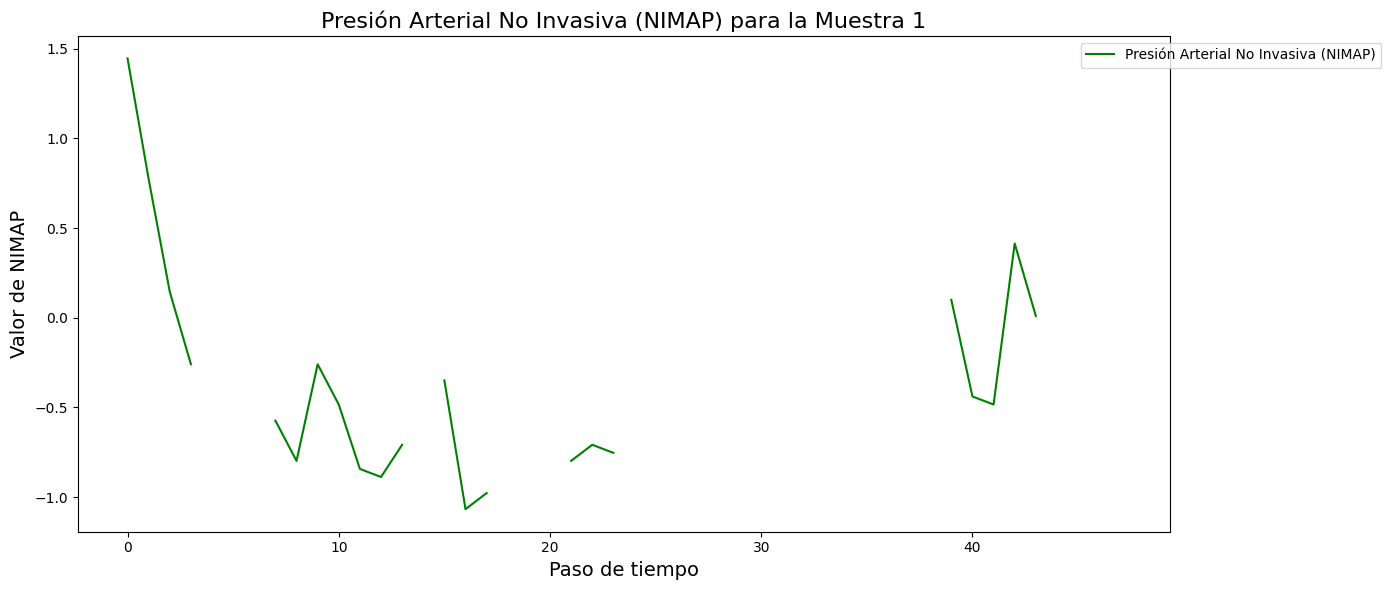

In [28]:
# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['NIMAP'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['NIMAP'], label='Presión Arterial No Invasiva (NIMAP)', color='g')
    plt.title(f'Presión Arterial No Invasiva (NIMAP) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de NIMAP', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Presión Arterial No Invasiva (NIMAP) en la muestra.")

# Mostrar los gráficos
plt.show()


In [29]:
dataset_for_training['X']

array([[[        nan,         nan,         nan, ...,         nan,
         -0.26666772,  0.0108424 ],
        [        nan,         nan,         nan, ..., -0.14063754,
                 nan,  0.00811628],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
         -0.04647074, -0.0109666 ],
        [        nan,         nan,         nan, ...,         nan,
         -0.04647074,         nan],
        [        nan,         nan,         nan, ...,         nan,
         -0.04647074,         nan]],

       [[-0.07717206, -0.3158438 , -0.30113704, ..., -0.0415    ,
          0.07149193,         nan],
        [        nan,         nan,         nan, ...,         nan,
          0.07149193,         nan],
        [        nan,         nan,         nan, ...,         nan,
          0.07149193,         nan],
        ...,
        [        nan,         nan,         nan, ...,  

In [30]:
physionet2012_dataset['n_steps']

48

In [31]:
physionet2012_dataset['n_features']

37

## 🚀 An example of **SAITS** for imputation

In [32]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=physionet2012_dataset['n_steps'],
    n_features=physionet2012_dataset['n_features'],
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    ##### Esto diferencia al SAIT del modelo Transformer
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=10,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)


2025-03-06 16:44:14 [INFO]: No given device, using default device: cpu
2025-03-06 16:44:14 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250306_T164414
2025-03-06 16:44:14 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250306_T164414/tensorboard
2025-03-06 16:44:14 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,378,358


In [33]:
# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
saits.fit(train_set=dataset_for_training, val_set=dataset_for_validating)


2025-03-06 16:44:48 [INFO]: Epoch 001 - training loss: 0.7304, validation loss: 0.3764
2025-03-06 16:45:21 [INFO]: Epoch 002 - training loss: 0.5373, validation loss: 0.3424
2025-03-06 16:45:57 [INFO]: Epoch 003 - training loss: 0.4899, validation loss: 0.3106
2025-03-06 16:46:30 [INFO]: Epoch 004 - training loss: 0.4570, validation loss: 0.2934
2025-03-06 16:47:06 [INFO]: Epoch 005 - training loss: 0.4308, validation loss: 0.2783
2025-03-06 16:47:39 [INFO]: Epoch 006 - training loss: 0.4099, validation loss: 0.2703
2025-03-06 16:48:15 [INFO]: Epoch 007 - training loss: 0.3969, validation loss: 0.2658
2025-03-06 16:48:48 [INFO]: Epoch 008 - training loss: 0.3839, validation loss: 0.2594
2025-03-06 16:49:24 [INFO]: Epoch 009 - training loss: 0.3763, validation loss: 0.2628
2025-03-06 16:49:57 [INFO]: Epoch 010 - training loss: 0.3683, validation loss: 0.2545
2025-03-06 16:49:57 [INFO]: Finished training. The best model is from epoch#10.
2025-03-06 16:49:58 [INFO]: Saved the model to tut

In [34]:
# the testing stage, impute the originally-missing values and artificially-missing values in the test set

saits_results = saits.predict(dataset_for_testing)
saits_imputation = saits_results["imputation"]


In [35]:
saits_imputation

array([[[-4.37465429e-01, -1.66988686e-01, -1.28562093e-01, ...,
         -1.21147089e-01, -3.29437637e+00, -6.44971943e-03],
        [-4.22716767e-01, -2.44347543e-01, -2.09285393e-01, ...,
         -1.06114015e-01, -1.97761208e-01, -1.50324218e-02],
        [-4.88474965e-01, -2.63982594e-01, -2.25716680e-01, ...,
         -9.78586376e-02, -2.23317876e-01, -1.55897588e-02],
        ...,
        [-4.96645987e-01, -1.69164121e-01, -1.83429807e-01, ...,
         -9.21572894e-02, -1.62368059e-01,  7.82031845e-03],
        [-5.35684109e-01, -2.05000401e-01, -1.89188614e-01, ...,
         -1.00175500e-01, -1.94226995e-01,  4.65130527e-03],
        [-4.40506130e-01, -1.77419737e-01, -1.69051647e-01, ...,
         -1.02453150e-01, -1.60945892e-01,  1.18000256e-02]],

       [[-5.64359128e-01, -2.47591108e-01, -1.41367227e-01, ...,
         -1.02303378e-01, -3.29437637e+00, -6.55938452e-03],
        [-5.71222544e-01, -3.14495325e-01, -2.32244402e-01, ...,
         -6.00298047e-02, -9.85670537e

In [36]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (2399, 48, 37)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (2399 * 48, 37)

X_reshaped = saits_imputation.reshape(-1, 37)

# Ahora X_reshaped tiene la forma (2399 * 48, 37)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(2399), range(48)], names=['Sample', 'Time'])

# Creamos el DataFrame
df_imputation = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df_imputation

Albumin       ALP       ALT       AST  Bilirubin       BUN  \
Sample Time                                                                
0      0    -0.437465 -0.166989 -0.128562  1.185449  -0.436728 -0.396313   
       1    -0.422717 -0.244348 -0.209285  0.901870  -0.377023 -0.359358   
       2    -0.488475 -0.263983 -0.225717  0.966138  -0.414088 -0.378663   
       3    -0.465284 -0.281038 -0.234928  0.848166  -0.441953 -0.414965   
       4    -0.542090 -0.278933 -0.233217  0.775446  -0.389379 -0.433026   
...               ...       ...       ...       ...        ...       ...   
2398   43   -0.450415 -0.170846 -0.117800  0.099203   0.292327 -0.196416   
       44   -0.240588 -0.165311 -0.153625 -0.090762   2.766181 -0.077733   
       45   -0.396083 -0.136518 -0.090655  0.170156   0.386296 -0.051105   
       46   -0.447112 -0.156442 -0.086954  0.101448   0.257768 -0.128664   
       47   -0.395305 -0.193455 -0.069481  0.107714   0.365450 -0.094885   

             Cholesterol  Creatinine   DiasABP      FiO2  ...  Platelets  \
Sample Time                                               ...              
0      0        0.232166   -0.360987  0.264661  0.334725  ...  -0.102168   
       1       -0.209628   -0.247307  0.144367 -0.295223  ...  -0.285808   
       2       -0.392192   -0.297338  0.018011 -0.316107  ...  -0.102168   
       3       -0.285674   -0.325762  0.099282 -0.254618  ...   0.081471   
       4       -0.742595   -0.280974 -0.070640 -0.271537  ...   0.081471   
...                  ...         ...       ...       ...  ...        ...   
2398   43      -1.228863    0.060736 -1.760116 -0.320819  ...  -0.341763   
       44      -0.392302    0.749063 -1.837668 -0.232244  ...  -0.393267   
       45      -1.030862    0.092015 -1.139700 -0.329693  ...  -0.183757   
       46      -1.318885    0.062380 -1.837668 -0.239173  ...  -0.246750   
       47      -0.981165    0.104823 -1.915220 -0.232741  ...  -0.270647   

             RespRate      SaO2    SysABP      Temp  TroponinI  TroponinT  \
Sample Time                                                                 
0      0    -0.115976  0.355935 -1.320034 -0.337720  -0.417741   2.390155   
       1     0.038918  0.232023 -0.689182 -0.375845  -0.355920  -0.568285   
       2     0.044036  0.076179 -0.526215 -0.297896  -0.420455   0.352119   
       3     0.119515  0.007943 -0.230849 -0.313214  -0.342704  -0.371055   
       4     0.100517 -0.096747  0.072945 -0.271606  -0.368422  -0.207167   
...               ...       ...       ...       ...        ...        ...   
2398   43    0.321704 -0.254141  0.054612 -0.161558  -0.376321  -0.568285   
       44    0.383416 -0.467325  0.051491 -0.657719  -0.319966  -0.568285   
       45    0.285242  0.854417  0.246054 -0.338267  -0.457380  -0.568285   
       46    0.309154 -0.040957  0.122854 -0.180156  -0.474865  -0.601156   
       47    0.301392 -0.382052  0.169660 -0.205366  -0.435059  -0.568285   

                Urine       WBC    Weight  
Sample Time                                
0      0    -0.121147 -3.294376 -0.006450  
       1    -0.106114 -0.197761 -0.015032  
       2    -0.097859 -0.223318 -0.015590  
       3    -0.072841 -0.194435 -0.005580  
       4    -0.088312 -0.210287 -0.012731  
...               ...       ...       ...  
2398   43   -0.073150  0.834317 -0.024805  
       44   -0.025786  0.834317  0.002664  
       45   -0.051153  0.834317 -0.018329  
       46   -0.054157  0.877509 -0.018878  
       47   -0.060856  0.867959 -0.016603  

[115152 rows x 37 columns]

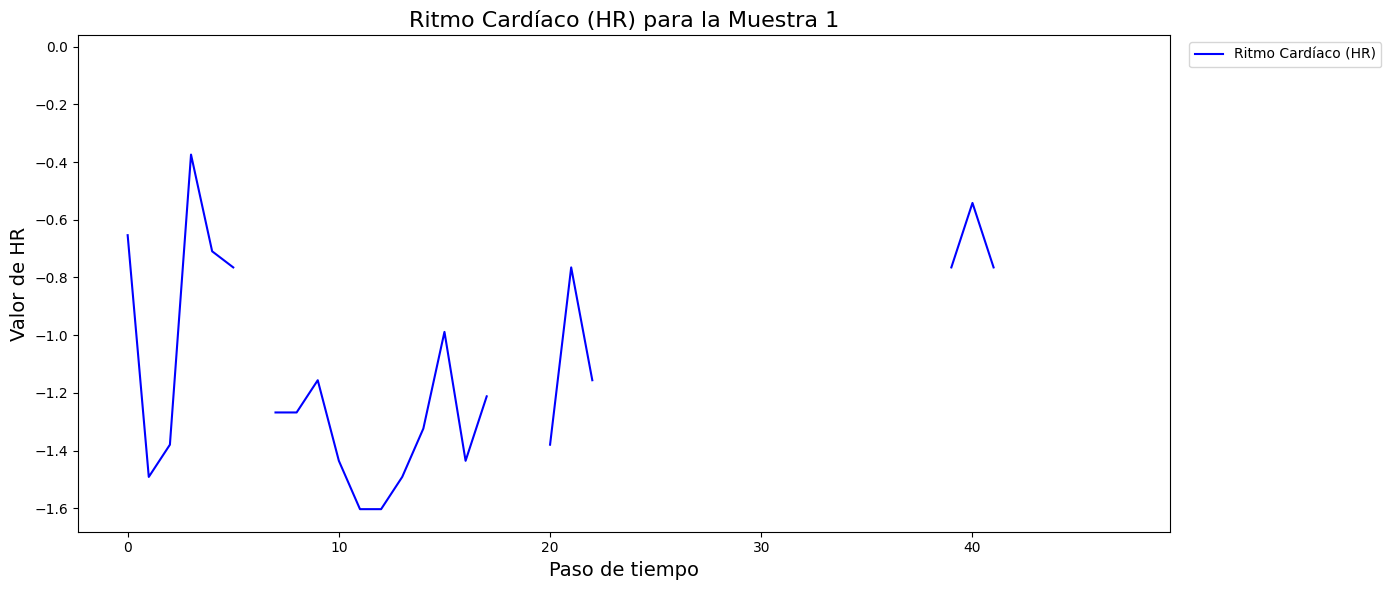

In [37]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(48)  # 48 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['HR', 'NIMAP']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['HR'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HR'], label='Ritmo Cardíaco (HR)', color='b')
    plt.title(f'Ritmo Cardíaco (HR) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HR', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Ritmo Cardíaco (HR) en la muestra.")



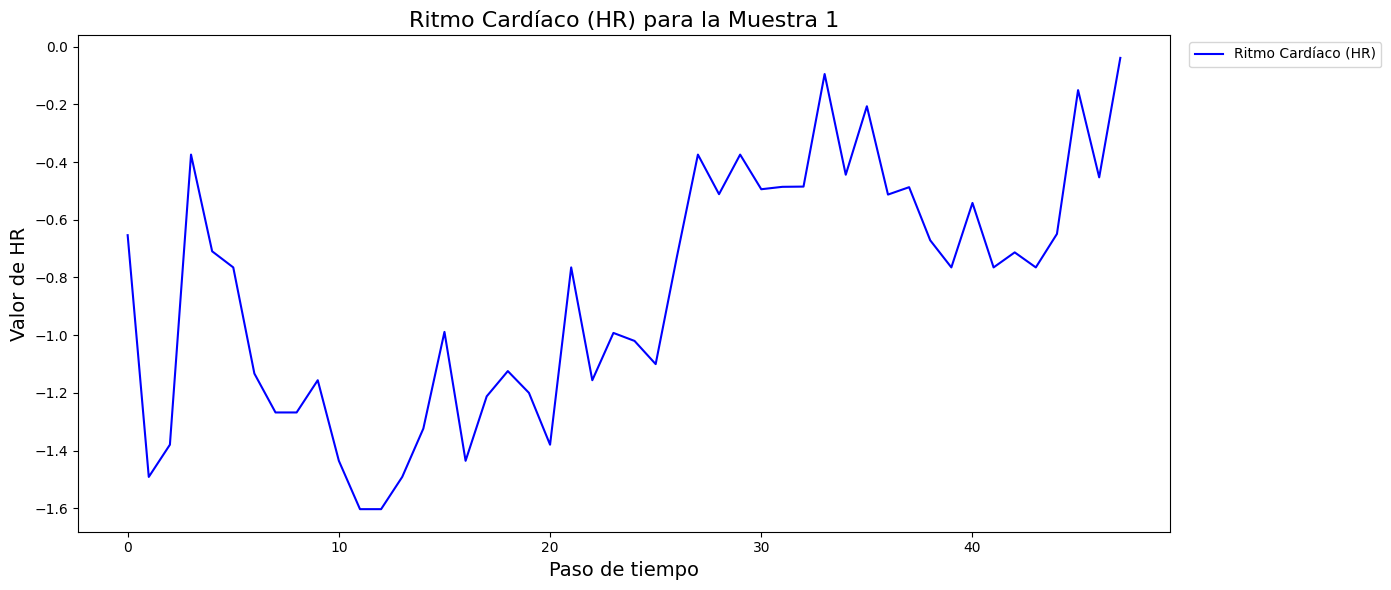

In [38]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(48)  # 48 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df_imputation.loc[sample_index, ['HR', 'NIMAP']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['HR'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HR'], label='Ritmo Cardíaco (HR)', color='b')
    plt.title(f'Ritmo Cardíaco (HR) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HR', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Ritmo Cardíaco (HR) en la muestra.")



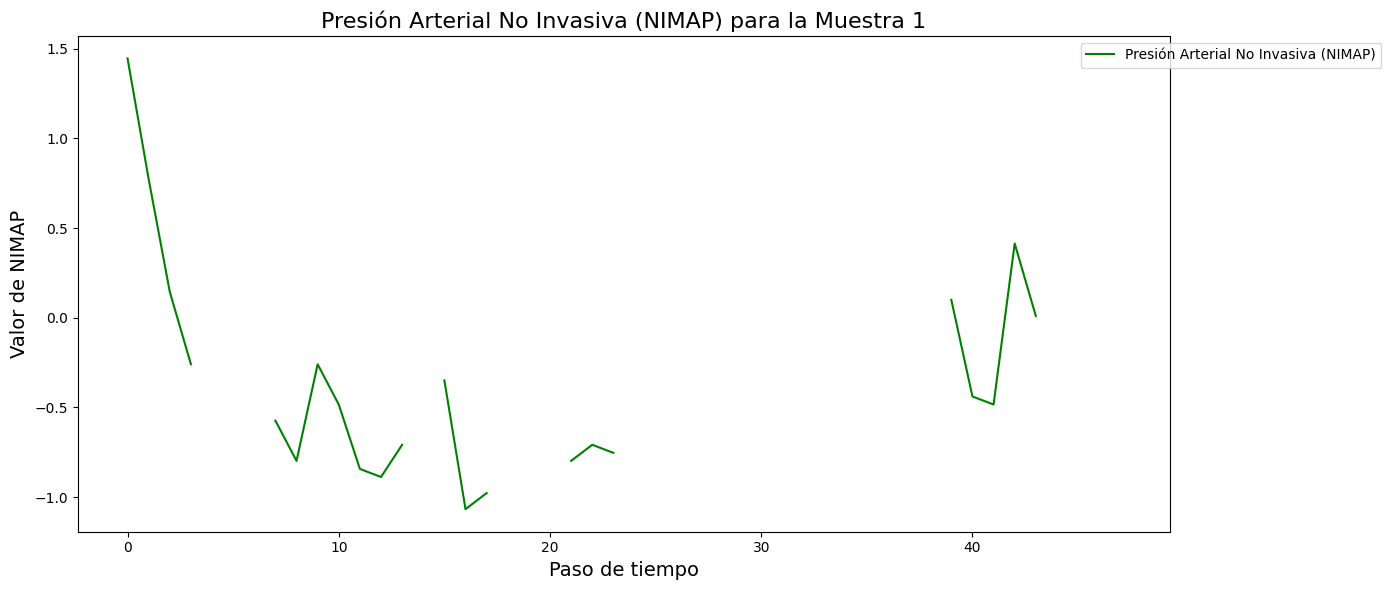

In [43]:
# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['HR', 'NIMAP']]

# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['NIMAP'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['NIMAP'], label='Presión Arterial No Invasiva (NIMAP)', color='g')
    plt.title(f'Presión Arterial No Invasiva (NIMAP) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de NIMAP', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Presión Arterial No Invasiva (NIMAP) en la muestra.")

# Mostrar los gráficos
plt.show()



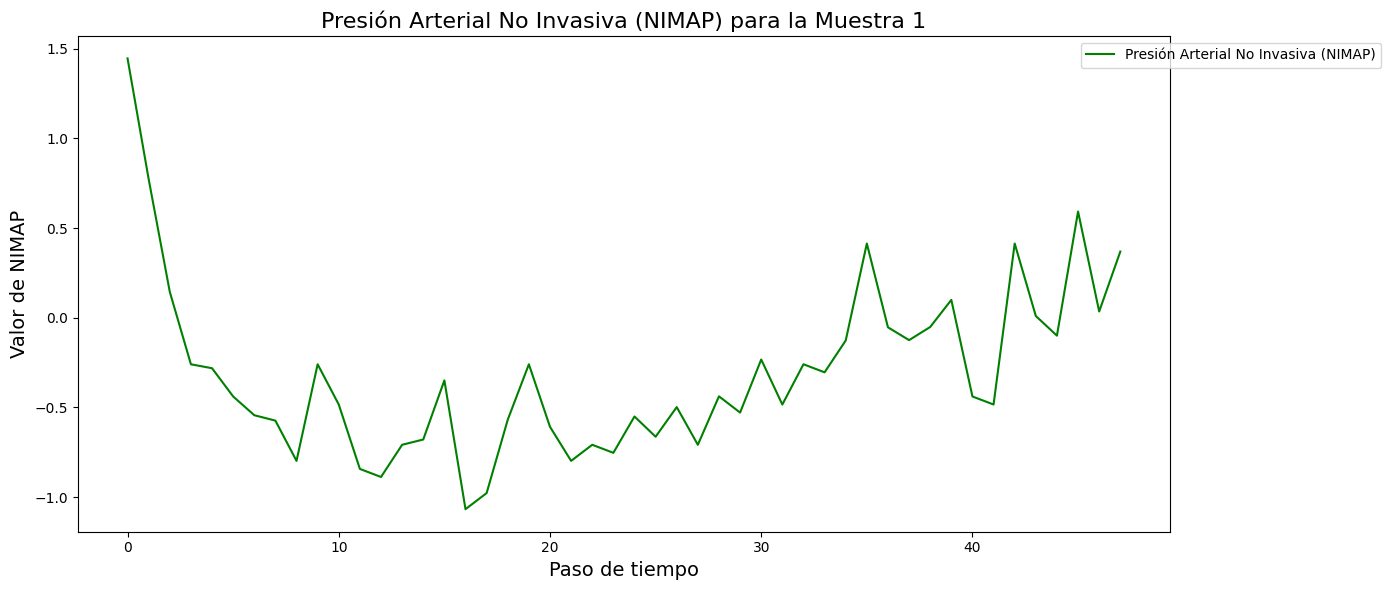

In [44]:
# Obtener los datos de la primera muestra para las características específicas
sample_data = df_imputation.loc[sample_index, ['HR', 'NIMAP']]

# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['NIMAP'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['NIMAP'], label='Presión Arterial No Invasiva (NIMAP)', color='g')
    plt.title(f'Presión Arterial No Invasiva (NIMAP) para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de NIMAP', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Presión Arterial No Invasiva (NIMAP) en la muestra.")

# Mostrar los gráficos
plt.show()

In [41]:
saits_imputation.shape

(2399, 48, 37)

In [42]:
from pypots.utils.metrics import calc_mae

physionet2012_dataset['test_X_indicating_mask'] = np.isnan(physionet2012_dataset['test_X']).astype(int)

# Crear una copia de los datos originales
test_X_ori_fixed = np.copy(physionet2012_dataset['test_X_ori'])

# Reemplazar NaNs por 0 (valor constante)
test_X_ori_fixed[np.isnan(test_X_ori_fixed)] = 0

# Verificar si quedan NaNs
num_nans_fixed = np.isnan(test_X_ori_fixed).sum()
print(f"Número de NaNs en test_X_ori después de imputación (con 0): {num_nans_fixed}")

# calculate mean absolute error on the ground truth (artificially-missing values)
# predictions, targets, masks
testing_mae = calc_mae(
    saits_imputation, 
    test_X_ori_fixed, 
    physionet2012_dataset['test_X_indicating_mask'],
)
print(f"Testing mean absolute error (MAE): {testing_mae:.4f}")

Número de NaNs en test_X_ori después de imputación (con 0): 0
Testing mean absolute error (MAE): 0.2968
